<a href="https://colab.research.google.com/github/aishamuqadus993-commits/Brain_tumor_detection/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Step 1: check your Drive root
drive_root = "/content/drive/MyDrive"
print("Folders in MyDrive:")
for folder in sorted(os.listdir(drive_root)):
    print(f"  '{folder}'")

Folders in MyDrive:
  'Colab Notebooks'
  'MRI Imgs'


In [ ]:
# -------- Import Libraries --------

import os                        # File and directory operations
import numpy as np               # Numerical operations
import random                    # For augmentation randomness
import pickle                    # Save/load MRI brain prototype for OOD rejection
import warnings                  # Suppress noisy TF/sklearn logs
warnings.filterwarnings('ignore')

from PIL import Image, ImageEnhance          # Image processing

# TensorFlow / Keras core
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K    # Keep ONLY if your Grad-CAM uses K.function style

# Evaluation and calibration
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score
)
from sklearn.utils import shuffle
from sklearn.covariance import EmpiricalCovariance

# OOD (Out-of-Distribution) rejection — feature distance
from scipy.spatial.distance import mahalanobis

# Realtime / concurrency / IO
import cv2
import threading
from queue import Queue, Empty
import time

In [ ]:
import os
import shutil
import random

# -------- CONFIG --------
DATASET_DIR  = "/content/drive/MyDrive/MRI Imgs"
OUTPUT_DIR   = "/content/drive/MyDrive/MRI_Imagess_split"
SPLIT_RATIOS = (0.7, 0.15, 0.15)
RANDOM_SEED  = 42

# -------- Make output dirs --------
splits = ["train", "val", "test"]

# FIX 1: filter out hidden/system folders explicitly
class_names = [
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
    and not d.startswith('.')          # removes .ipynb_checkpoints etc
    and not d.startswith('__')         # removes __MACOSX etc
]

# FIX 2: early exit if no classes found
if not class_names:
    raise ValueError(f"No class folders found in {DATASET_DIR}. Check your path.")

print(f"Classes found: {class_names}\n")

for split in splits:
    for cls in class_names:
        os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

# -------- Split each class --------
random.seed(RANDOM_SEED)

total_train = total_val = total_test = 0   # for final summary

for cls in class_names:
    cls_dir = os.path.join(DATASET_DIR, cls)
    images = [
        f for f in os.listdir(cls_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    # FIX 3: skip empty class folders with a warning instead of silently failing
    if len(images) == 0:
        print(f"WARNING: No images found in class '{cls}', skipping.")
        continue

    random.shuffle(images)
    n_total = len(images)
    n_train = int(SPLIT_RATIOS[0] * n_total)
    n_val   = int(SPLIT_RATIOS[1] * n_total)
    n_test  = n_total - n_train - n_val     # remainder to test, no images lost

    train_imgs = images[:n_train]
    val_imgs   = images[n_train:n_train + n_val]
    test_imgs  = images[n_train + n_val:]

    for fname in train_imgs:
        shutil.copy(os.path.join(cls_dir, fname), os.path.join(OUTPUT_DIR, "train", cls, fname))
    for fname in val_imgs:
        shutil.copy(os.path.join(cls_dir, fname), os.path.join(OUTPUT_DIR, "val",   cls, fname))
    for fname in test_imgs:
        shutil.copy(os.path.join(cls_dir, fname), os.path.join(OUTPUT_DIR, "test",  cls, fname))

    total_train += len(train_imgs)
    total_val   += len(val_imgs)
    total_test  += len(test_imgs)

    print(f"  {cls:20s} → total={n_total:4d} | train={len(train_imgs):4d} | val={len(val_imgs):4d} | test={len(test_imgs):4d}")

# -------- Final summary --------
print(f"\n{'─'*55}")
print(f"  TOTAL               → train={total_train} | val={total_val} | test={total_test}")
print(f"  Grand total images  → {total_train + total_val + total_test}")
print(f"\n✅ Dataset split complete. Saved to: {OUTPUT_DIR}")

Classes found: ['no_tumor', 'meningioma', 'glioma', 'pituitary']

  no_tumor             → total=1757 | train=1229 | val= 263 | test= 265
  meningioma           → total=2343 | train=1640 | val= 351 | test= 352
  glioma               → total=3754 | train=2627 | val= 563 | test= 564
  pituitary            → total=2706 | train=1894 | val= 405 | test= 407

───────────────────────────────────────────────────────
  TOTAL               → train=7390 | val=1582 | test=1588
  Grand total images  → 10560

✅ Dataset split complete. Saved to: /content/drive/MyDrive/MRI_Imagess_split


  glioma               → 3754 images found
  meningioma           → 2343 images found
  no_tumor             → 1757 images found
  pituitary            → 2706 images found


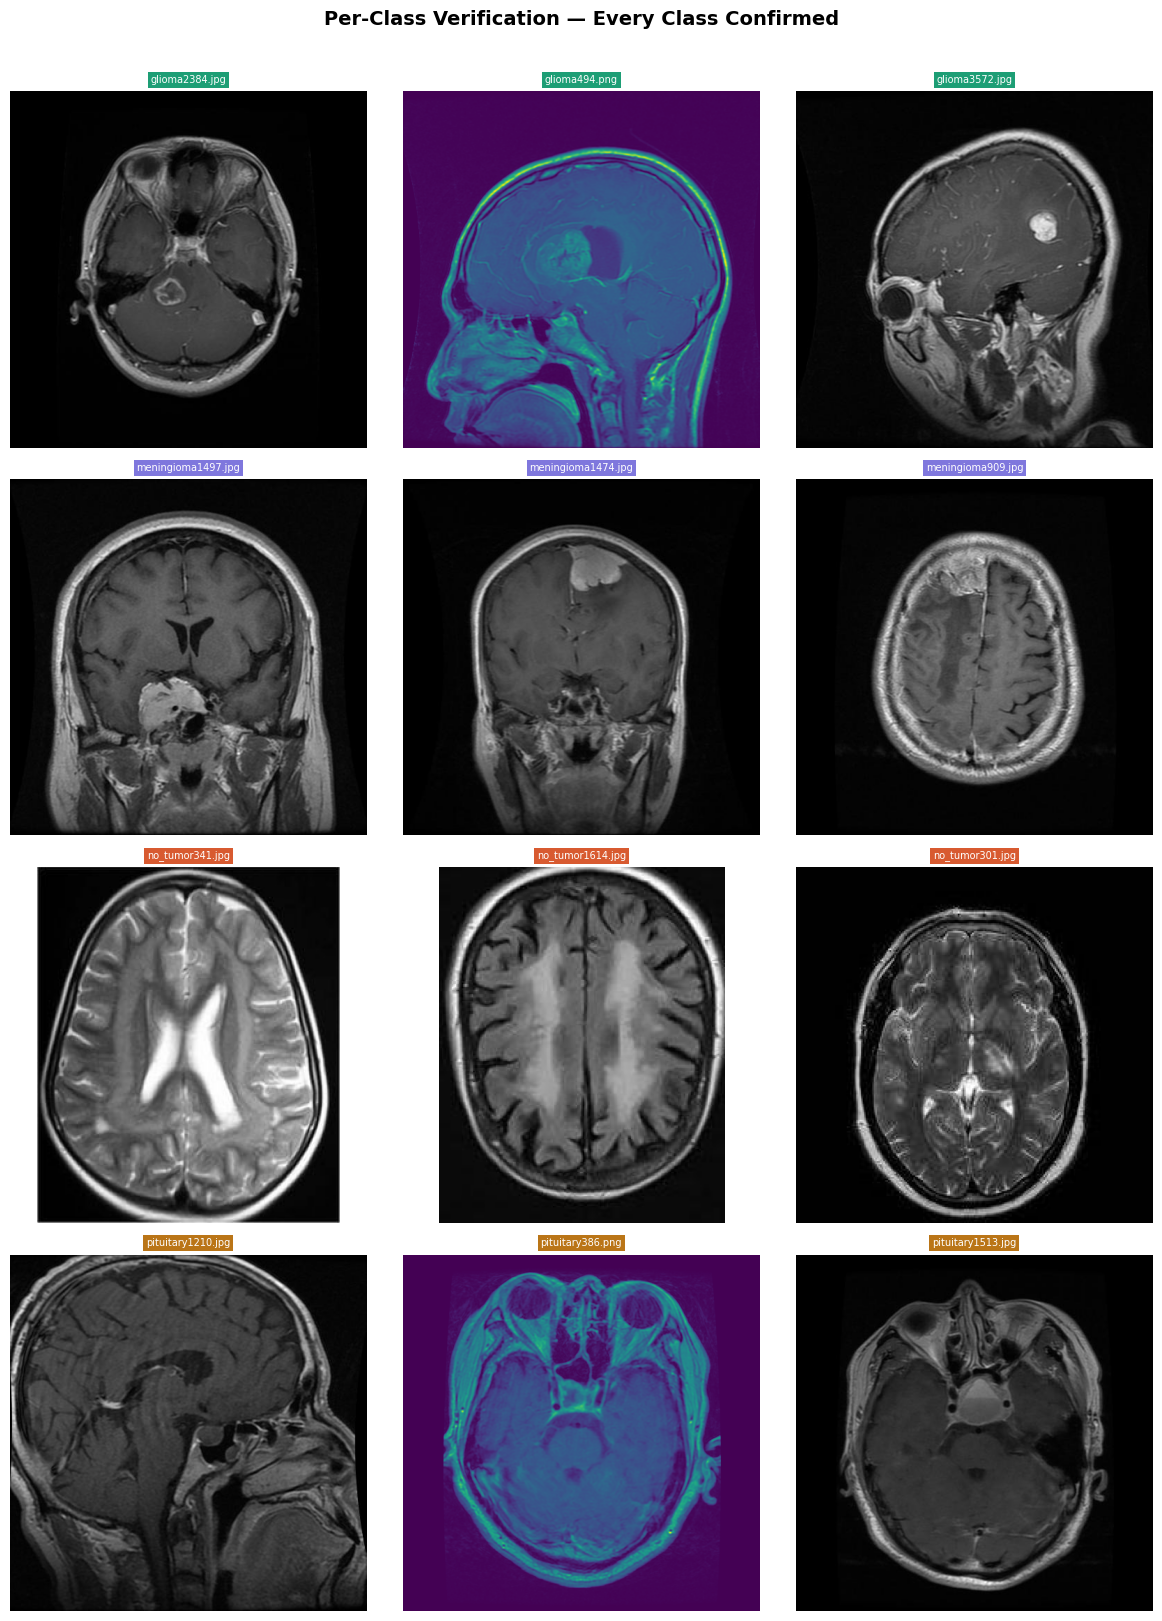


✅ Per-class verification complete.


In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

DATASET_DIR = "/content/drive/MyDrive/MRI Imgs"
SAMPLES_PER_CLASS = 3
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

class_names = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
    and not d.startswith('.') and not d.startswith('__')
])

colors = {
    'glioma':      '#1D9E75',
    'meningioma':  '#7F77DD',
    'no_tumor':    '#D85A30',
    'pituitary':   '#BA7517'
}

cols = SAMPLES_PER_CLASS
rows = len(class_names)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
fig.suptitle("Per-Class Verification — Every Class Confirmed",
             fontsize=14, fontweight='bold', y=1.01)

for r, cls in enumerate(class_names):
    cls_dir = os.path.join(DATASET_DIR, cls)
    all_imgs = [
        f for f in os.listdir(cls_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    # print count so you can confirm numbers
    print(f"  {cls:20s} → {len(all_imgs):4d} images found")

    sampled = random.sample(all_imgs, min(SAMPLES_PER_CLASS, len(all_imgs)))

    for c, fname in enumerate(sampled):
        ax = axes[r][c]
        img = Image.open(os.path.join(cls_dir, fname)).convert('RGB')
        ax.imshow(img)

        # first column shows class label
        if c == 0:
            ax.set_ylabel(cls, fontsize=13, fontweight='bold',
                         color=colors.get(cls, '#444'),
                         rotation=0, labelpad=70, va='center')

        # show filename so you can manually verify if needed
        ax.set_title(fname[:25], fontsize=7,
                     color='white',
                     bbox=dict(facecolor=colors.get(cls,'#444'),
                               edgecolor='none', pad=2))
        ax.axis('off')

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(colors.get(cls, '#444'))
            spine.set_linewidth(3)

plt.tight_layout()
plt.savefig("per_class_verification.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Per-class verification complete.")


In [ ]:

import os, cv2, random, pickle
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.utils import to_categorical
from sklearn.utils import shuffle

# ── Config
IMAGE_SIZE     = 224
BATCH_SIZE     = 32
RANDOM_SEED    = 42
PROTOTYPE_PATH = "/content/drive/MyDrive/mri_brain_prototype.pkl"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── OOD thresholds
OOD_CONFIG = {
    "mahalanobis_threshold" : 12.0,
    "confidence_threshold"  : 0.55,
    "entropy_threshold"     : 0.90,
    "min_dark_pixel_ratio"  : 0.05,
    "max_saturation"        : 160,
    "min_parallel_lines"    : 30,
    "max_edge_density"      : 0.10,
}

# 1. CLASS NAMES

def get_class_names_from_dir(train_dir):
    classes = sorted([
        d for d in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, d))
        and not d.startswith('.') and not d.startswith('__')
    ])
    if not classes:
        raise ValueError(f"No class folders in {train_dir}")
    print(f"  Classes: {classes}")
    return classes


# 2. OOD PIXEL CHECK (CT rejection skipped)

def ood_pixel_check(img_bgr):
    failures = []
    gray     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hsv      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    mean_sat = float(hsv[:, :, 1].mean())
    if mean_sat > 180:
        return False, f"Clearly a natural photo (sat={mean_sat:.1f})"

    dark_ratio = float(np.sum(gray < 30) / gray.size)
    if dark_ratio < OOD_CONFIG["min_dark_pixel_ratio"]:
        failures.append(f"no dark bg ({dark_ratio:.3f})")

    if mean_sat > OOD_CONFIG["max_saturation"]:
        failures.append(f"high saturation ({mean_sat:.1f})")

    edges          = cv2.Canny(gray, 50, 150)
    lines          = cv2.HoughLinesP(edges, 1, np.pi/180,
                        threshold=80, minLineLength=60, maxLineGap=10)
    parallel_lines = len(lines) if lines is not None else 0
    edge_density   = float(edges.sum() / (gray.size * 255))

    if (edge_density   > OOD_CONFIG["max_edge_density"] and
        parallel_lines > OOD_CONFIG["min_parallel_lines"]):
        failures.append(f"X-ray pattern ({parallel_lines} lines)")

    if len(failures) >= 2:
        return False, " + ".join(failures)

    return True, "passed"


# 3. AUGMENTATION

def augment_image(image_arr):
    if random.random() < 0.5:
        image_arr = np.fliplr(image_arr)
    if random.random() < 0.3:
        image_arr = np.flipud(image_arr)
    factor    = random.uniform(0.85, 1.15)
    image_arr = np.clip(image_arr * factor, 0, 255)
    if random.random() < 0.5:
        angle     = random.uniform(-15, 15)
        h, w      = image_arr.shape[:2]
        M         = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        image_arr = cv2.warpAffine(image_arr.astype(np.float32), M, (w, h),
                        flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
    if random.random() < 0.4:
        scale     = random.uniform(0.85, 1.0)
        h, w      = image_arr.shape[:2]
        new_h, new_w = int(h*scale), int(w*scale)
        top, left = (h-new_h)//2, (w-new_w)//2
        cropped   = image_arr[top:top+new_h, left:left+new_w]
        image_arr = cv2.resize(cropped, (w, h), interpolation=cv2.INTER_LINEAR)
    return image_arr.astype(np.float32)

# 4. IMAGE LOADER

def open_images(paths, image_size=IMAGE_SIZE,
                augment=False, ood_check=False):
    imgs = []
    for p in paths:
        try:
            if ood_check:
                img_bgr = cv2.imread(p)
                if img_bgr is None:
                    continue
                img_bgr_r      = cv2.resize(img_bgr, (image_size, image_size))
                passed, reason = ood_pixel_check(img_bgr_r)
                if not passed:
                    print(f"  [REJECT] {os.path.basename(p)}: {reason}")
                    continue
            img = load_img(p, target_size=(image_size, image_size))
            arr = img_to_array(img).astype(np.float32)
            if augment:
                arr = augment_image(arr)
            arr = preprocess_input(arr)
            imgs.append(arr)
        except Exception as e:
            print(f"  [WARN] skip {os.path.basename(p)}: {e}")

    if len(imgs) == 0:
        return np.zeros((0, image_size, image_size, 3), dtype=np.float32)
    return np.stack(imgs, axis=0)

# 5. LABEL ENCODER

def encode_multiclass(labels, class_names):
    idx = [class_names.index(l) for l in labels]
    return to_categorical(idx, num_classes=len(class_names))

# 6. DATA GENERATOR

def datagen_oversample(paths, labels, class_names,
                       batch_size=BATCH_SIZE, image_size=IMAGE_SIZE,
                       augment=False):
    class_pools = {cls: [] for cls in class_names}
    for p, l in zip(paths, labels):
        class_pools[l].append(p)

    max_count    = max(len(v) for v in class_pools.values())
    balanced     = []
    for cls in class_names:
        pool      = class_pools[cls]
        oversampl = (pool * ((max_count // len(pool)) + 1))[:max_count]
        balanced += [(p, cls) for p in oversampl]

    print(f"  Generator: {len(balanced)} samples, "
          f"{max_count} per class, "
          f"{max(1, len(balanced)//batch_size)} steps/epoch")

    while True:
        pool_sh = shuffle(balanced, random_state=random.randint(0, 9999))
        for i in range(0, len(pool_sh), batch_size):
            batch  = pool_sh[i:i+batch_size]
            X = open_images([b[0] for b in batch],
                            image_size=image_size, augment=augment)
            y = encode_multiclass([b[1] for b in batch], class_names)
            if len(X) == 0:
                continue
            yield X, y


# 7. CLASS WEIGHTS

def compute_class_weights(labels, class_names):
    from sklearn.utils.class_weight import compute_class_weight
    idx     = [class_names.index(l) for l in labels]
    weights = compute_class_weight('balanced',
                classes=np.arange(len(class_names)), y=idx)
    w_dict  = {i: w for i, w in enumerate(weights)}
    for i, cls in enumerate(class_names):
        print(f"  {cls:<20} → {w_dict[i]:.4f}")
    return w_dict

# 8. PROTOTYPE BUILDER

def build_brain_mri_prototype(train_dir, class_names, feat_extractor,
                               save_path=PROTOTYPE_PATH,
                               max_per_class=50,   # ← kept low to avoid disconnect
                               batch_size=16):
    from sklearn.covariance import EmpiricalCovariance
    all_features = []
    print("\nBuilding prototype...")

    for cls in class_names:
        cls_dir      = os.path.join(train_dir, cls)
        images       = [f for f in os.listdir(cls_dir)
                        if f.lower().endswith(('.jpg','.jpeg','.png'))]
        images       = random.sample(images, min(max_per_class, len(images)))
        batch_arrays = []

        for fname in images:
            try:
                img = load_img(os.path.join(cls_dir, fname),
                               target_size=(IMAGE_SIZE, IMAGE_SIZE))
                arr = preprocess_input(img_to_array(img).astype(np.float32))
                batch_arrays.append(arr)
            except:
                continue

            # predict whole batch at once — not one by one
            if len(batch_arrays) == batch_size:
                feats = feat_extractor.predict(
                    np.stack(batch_arrays), verbose=0)
                all_features.extend(feats.tolist())
                batch_arrays = []

        # leftover batch
        if batch_arrays:
            feats = feat_extractor.predict(
                np.stack(batch_arrays), verbose=0)
            all_features.extend(feats.tolist())

        print(f"  ✅ {cls}: done")

    all_features = np.array(all_features)
    mean_vec     = np.mean(all_features, axis=0)
    cov_model    = EmpiricalCovariance().fit(all_features)
    cov_inv      = np.linalg.inv(
        cov_model.covariance_ +
        np.eye(cov_model.covariance_.shape[0]) * 1e-6)

    prototype = {"mean": mean_vec, "cov_inv": cov_inv}
    with open(save_path, "wb") as f:
        pickle.dump(prototype, f)
    print(f"  ✅ Prototype saved → {save_path}")
    return prototype

def load_prototype(path=PROTOTYPE_PATH):
    with open(path, "rb") as f:
        return pickle.load(f)


# 9. STEPS

def get_steps(num_samples, batch_size=BATCH_SIZE):
    return max(1, num_samples // batch_size)

print("✅ preprocessing.py loaded.")

✅ preprocessing.py loaded.


In [ ]:
import os
import math
import json
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dropout, Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.losses import CategoricalCrossentropy

# CONFIG — single place

TRAIN_DIR     = "/content/drive/MyDrive/MRI_Imagess_split/train"
VAL_DIR       = "/content/drive/MyDrive/MRI_Imagess_split/val"
TEST_DIR      = "/content/drive/MyDrive/MRI_Imagess_split/test"
MODEL_OUT_DIR = "/content/drive/MyDrive/model_artifacts"
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

IMAGE_SIZE    = 224
BATCH_SIZE    = 32
EPOCHS_P1     = 10   # phase 1: frozen backbone
EPOCHS_P2     = 15   # phase 2: fine-tune last layers
LABEL_SMOOTH  = 0.1
LR_PHASE1     = 1e-3
LR_PHASE2     = 1e-4


# STEP 1 — class names and paths

CLASS_NAMES = get_class_names_from_dir(TRAIN_DIR)
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes : {CLASS_NAMES}")
print(f"Num classes: {NUM_CLASSES}")

# STEP 2 — gather paths and labels

def gather_paths_labels(root_dir, class_names):
    paths, labels = [], []
    for cls in class_names:          # iterate in sorted order from class_names
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            print(f"  [WARN] missing folder: {cls_dir}")
            continue
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                paths.append(os.path.join(cls_dir, fname))
                labels.append(cls)   # keep original casing, matches CLASS_NAMES
    return paths, labels

train_paths, train_labels = gather_paths_labels(TRAIN_DIR, CLASS_NAMES)
val_paths,   val_labels   = gather_paths_labels(VAL_DIR,   CLASS_NAMES)
test_paths,  test_labels  = gather_paths_labels(TEST_DIR,  CLASS_NAMES)

print(f"\nTrain : {len(train_paths)} images")
print(f"Val   : {len(val_paths)} images")
print(f"Test  : {len(test_paths)} images")


# STEP 3 — class weights for imbalance correction

class_weights = compute_class_weights(train_labels, CLASS_NAMES)


# STEP 4 — generators


# balanced pool size = max_class_count × num_classes
max_class_count = max(
    sum(1 for l in train_labels if l == cls)
    for cls in CLASS_NAMES
)
balanced_train_size = max_class_count * NUM_CLASSES
steps_per_epoch  = get_steps(balanced_train_size, BATCH_SIZE)
validation_steps = get_steps(len(val_paths),      BATCH_SIZE)

print(f"\nBalanced train size : {balanced_train_size}")
print(f"Steps per epoch     : {steps_per_epoch}")
print(f"Validation steps    : {validation_steps}")

# train generator — uses fixed datagen_oversample from preprocessing
train_gen = datagen_oversample(
    train_paths, train_labels, CLASS_NAMES,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    augment=True
)

# val generator — simple, no oversampling, no augmentation
def val_generator(paths, labels, class_names,
                  batch_size=BATCH_SIZE, image_size=IMAGE_SIZE):
    """
    Clean validation generator.
    Loops once per epoch over real val images only.
    No oversampling, no augmentation — we want true val performance.
    """
    pool = list(zip(paths, labels))
    while True:
        random.shuffle(pool)
        for i in range(0, len(pool), batch_size):
            batch        = pool[i:i + batch_size]
            batch_paths  = [b[0] for b in batch]
            batch_labels = [b[1] for b in batch]
            X = open_images(batch_paths,
                            image_size=image_size,
                            augment=False,
                            ood_check=False)
            y = encode_multiclass(batch_labels, class_names)
            if len(X) == 0:
                continue
            yield X, y

val_gen = val_generator(val_paths, val_labels, CLASS_NAMES)

# wrap both as tf.data for prefetching — faster on T4
train_ds = tf.data.Dataset.from_generator(
    lambda: train_gen,
    output_signature=(
        tf.TensorSpec(shape=(None, IMAGE_SIZE, IMAGE_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, NUM_CLASSES),               dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_generator(
    lambda: val_gen,
    output_signature=(
        tf.TensorSpec(shape=(None, IMAGE_SIZE, IMAGE_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, NUM_CLASSES),               dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

# STEP 5 — build model

def build_model(num_classes, image_size=IMAGE_SIZE):
    base = VGG16(
        include_top=False,
        weights='imagenet',
        input_shape=(image_size, image_size, 3)
    )
    # freeze entire backbone for phase 1
    for layer in base.layers:
        layer.trainable = False

    x = base.output
    x = Flatten()(x)
    x = Dropout(0.5)(x)           # increased from 0.3 — reduces overfitting
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)           # increased from 0.2
    x = Dense(128, activation='relu')(x)   # extra layer for better features
    x = Dropout(0.2)(x)
    out = Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=base.input, outputs=out)
    return model, base

model, base = build_model(NUM_CLASSES)

model.compile(
    optimizer=Adam(learning_rate=LR_PHASE1),
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy']
)

model.summary()

# STEP 6 — callbacks (reused across both phases)

def make_callbacks(ckpt_path, phase_name):
    return [
        ModelCheckpoint(
            ckpt_path,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1,
            mode='max'
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=6,
            restore_best_weights=True,
            mode='max',
            verbose=1
        )
    ]

ckpt_p1 = os.path.join(MODEL_OUT_DIR, 'vgg16_phase1_best.keras')
ckpt_p2 = os.path.join(MODEL_OUT_DIR, 'vgg16_phase2_best.keras')


# STEP 7 — phase 1 training (frozen backbone)

print("\n" + "="*55)
print("  PHASE 1 — Training classifier head (backbone frozen)")
print("="*55)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P1,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=make_callbacks(ckpt_p1, 'phase1'),
    class_weight=class_weights    # handles no_tumor imbalance
)

print(f"\n  Phase 1 best val_accuracy: "
      f"{max(history1.history['val_accuracy']):.4f}")


# STEP 8 — phase 2 fine-tuning (unfreeze last 8 backbone layers)
print("\n" + "="*55)
print("  PHASE 2 — Fine-tuning (last 8 backbone layers unfrozen)")
print("="*55)

# unfreeze last 8 layers of VGG16 backbone
for layer in base.layers:
    layer.trainable = False       # reset all first
for layer in base.layers[-8:]:
    layer.trainable = True        # then unfreeze only last 8

# recompile with lower LR — critical for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=LR_PHASE2),
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy']
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P2,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=make_callbacks(ckpt_p2, 'phase2'),
    class_weight=class_weights
)

print(f"\n  Phase 2 best val_accuracy: "
      f"{max(history2.history['val_accuracy']):.4f}")


# STEP 9 — evaluation on validation set

print("\n" + "="*55)
print("  EVALUATION on validation set")
print("="*55)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# evaluate in batches — avoids RAM crash on full val set
all_preds, all_trues = [], []
pool = list(zip(val_paths, val_labels))

for i in range(0, len(pool), BATCH_SIZE):
    batch        = pool[i:i + BATCH_SIZE]
    batch_paths  = [b[0] for b in batch]
    batch_labels = [b[1] for b in batch]
    X = open_images(batch_paths,
                    image_size=IMAGE_SIZE,
                    augment=False,
                    ood_check=False)
    if len(X) == 0:
        continue
    preds = model.predict(X, verbose=0)
    all_preds.extend(np.argmax(preds,  axis=1).tolist())
    all_trues.extend(
        [CLASS_NAMES.index(l) for l in batch_labels]
    )

all_preds = np.array(all_preds)
all_trues = np.array(all_trues)

val_acc = accuracy_score(all_trues, all_preds)
print(f"\n  Validation accuracy : {val_acc:.4f}")
print(f"\n  Classification report:")
print(classification_report(
    all_trues, all_preds,
    target_names=CLASS_NAMES,
    digits=4
))
print("  Confusion matrix:")
print(confusion_matrix(all_trues, all_preds))

# STEP 10 — save final model + metadata

final_model_path = os.path.join(MODEL_OUT_DIR, 'vgg16_final.keras')
model.save(final_model_path)
print(f"\n  Final model saved: {final_model_path}")

metadata = {
    "CLASS_NAMES"    : CLASS_NAMES,
    "NUM_CLASSES"    : NUM_CLASSES,
    "IMAGE_SIZE"     : IMAGE_SIZE,
    "BATCH_SIZE"     : BATCH_SIZE,
    "EPOCHS_P1"      : EPOCHS_P1,
    "EPOCHS_P2"      : EPOCHS_P2,
    "preprocessing"  : "vgg16_preprocess_input",
    "label_smoothing": LABEL_SMOOTH,
    "architecture"   : "VGG16 + Flatten + Dense(256) + Dense(128) + Softmax(4)",
    "phase2_unfrozen": "last 8 VGG16 layers"
}

meta_path = os.path.join(MODEL_OUT_DIR, "metadata.json")
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"  Metadata saved: {meta_path}")

print("\n  Training complete!")
print(f"  Phase 1 checkpoint → {ckpt_p1}")
print(f"  Phase 2 checkpoint → {ckpt_p2}")
print(f"  Final model        → {final_model_path}")

  Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Classes : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Num classes: 4

Train : 7390 images
Val   : 1582 images
Test  : 1588 images
  glioma               → 0.7033
  meningioma           → 1.1265
  no_tumor             → 1.5033
  pituitary            → 0.9754

Balanced train size : 10508
Steps per epoch     : 328
Validation steps    : 49
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             

 Total params: 21,170,884 (80.76 MB)

 Trainable params: 6,456,196 (24.63 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


  PHASE 1 — Training classifier head (backbone frozen)
Epoch 1/10
  Generator: 10508 samples, 2627 per class, 328 steps/epoch
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.5342 - loss: 5.9106
Epoch 1: val_accuracy improved from None to 0.73214, saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase1_best.keras
328/328 ━━━━━━━━━━━━━━━━━━━━ 153s 404ms/step - accuracy: 0.5990 - loss: 2.5464 - val_accuracy: 0.7321 - val_loss: 0.8986 - learning_rate: 0.0010
Epoch 2/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.6684 - loss: 1.0590
Epoch 2: val_accuracy improved from 0.73214 to 0.78645, saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase1_best.keras
328/328 ━━━━━━━━━━━━━━━━━━━━ 144s 407ms/step - accuracy: 0.6837 - loss: 1.0361 - val_accuracy: 0.786

In [ ]:
# Run this ALONE after training completes — separate cell
flatten   = next(l for l in model.layers if 'flatten' in l.name.lower())
extractor = Model(inputs=model.input, outputs=flatten.output)

build_brain_mri_prototype(
    train_dir      = TRAIN_DIR,
    class_names    = CLASS_NAMES,
    feat_extractor = extractor,
    save_path      = PROTOTYPE_PATH,
    max_per_class  = 50,    # 50 per class = 200 total, fast enough
    batch_size     = 16
)


Building prototype...
  ✅ glioma: done
  ✅ meningioma: done
  ✅ no_tumor: done
  ✅ pituitary: done


In [ ]:
import os
path = "/content/drive/MyDrive/model_artifacts/vgg16_phase2_best.keras"
print(os.path.exists(path), os.path.getsize(path), "bytes")

True 240277009 bytes


In [ ]:
import json
import os
from tensorflow.keras.models import load_model # Import load_model

# Define MODEL_OUT_DIR for robustness if it's not in global scope
MODEL_OUT_DIR = "/content/drive/MyDrive/model_artifacts"

# Define other required variables for metadata (copied from training cell)
CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary'] # Assuming these are the class names
NUM_CLASSES = len(CLASS_NAMES)
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS_P1 = 10
EPOCHS_P2 = 15
LABEL_SMOOTH = 0.1

# ── Save final model
final_path = os.path.join(MODEL_OUT_DIR, 'vgg16_final.keras')
# Load the model before saving it, in case the kernel state was reset
model = load_model(final_path) # Load the model to ensure it's defined
model.save(final_path)
print(f"✅ Final model saved → {final_path}")

# ── Save metadata
metadata = {
    "CLASS_NAMES"    : CLASS_NAMES,
    "NUM_CLASSES"    : NUM_CLASSES,
    "IMAGE_SIZE"     : IMAGE_SIZE,
    "BATCH_SIZE"     : BATCH_SIZE,
    "EPOCHS_P1"      : EPOCHS_P1,
    "EPOCHS_P2"      : EPOCHS_P2,
    "preprocessing"  : "vgg16_preprocess_input",
    "label_smoothing": LABEL_SMOOTH,
    "architecture"   : "VGG16 + Flatten + Dense(256) + Dense(128) + Softmax(4)",
    "phase2_unfrozen": "last 8 VGG16 layers"
}

meta_path = os.path.join(MODEL_OUT_DIR, "metadata.json")
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Metadata saved  → {meta_path}")

✅ Final model saved → /content/drive/MyDrive/model_artifacts/vgg16_final.keras
✅ Metadata saved  → /content/drive/MyDrive/model_artifacts/metadata.json


Loading model...
✅ Model loaded.
Val: 1582 | Test: 1588

  EVALUATION — Validation

  Accuracy: 0.9880 (98.80%)
              precision    recall  f1-score   support

      glioma     0.9946    0.9840    0.9893       563
  meningioma     0.9801    0.9829    0.9815       351
    no_tumor     0.9848    0.9886    0.9867       263
   pituitary     0.9878    0.9975    0.9926       405

    accuracy                         0.9880      1582
   macro avg     0.9868    0.9883    0.9875      1582
weighted avg     0.9880    0.9880    0.9880      1582



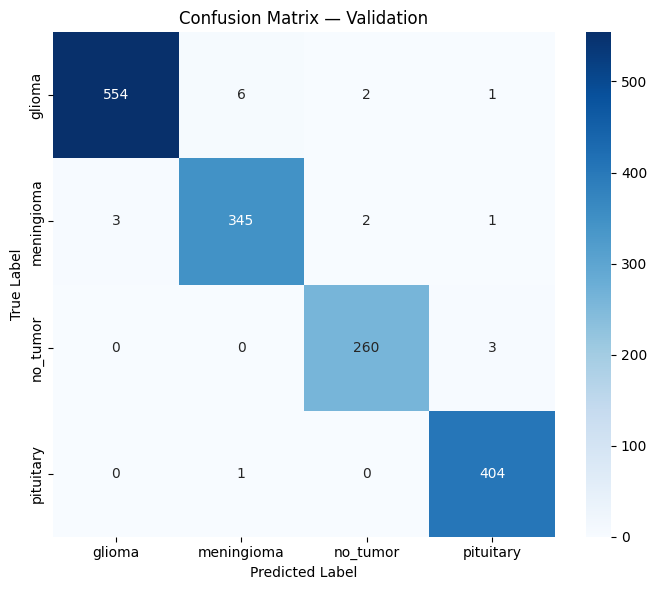

  ✅ Saved → /content/drive/MyDrive/model_artifacts/cm_validation.png

  EVALUATION — Test

  Accuracy: 0.9868 (98.68%)
              precision    recall  f1-score   support

      glioma     0.9859    0.9894    0.9876       564
  meningioma     0.9885    0.9801    0.9843       352
    no_tumor     0.9849    0.9849    0.9849       265
   pituitary     0.9877    0.9902    0.9890       407

    accuracy                         0.9868      1588
   macro avg     0.9868    0.9861    0.9864      1588
weighted avg     0.9868    0.9868    0.9868      1588



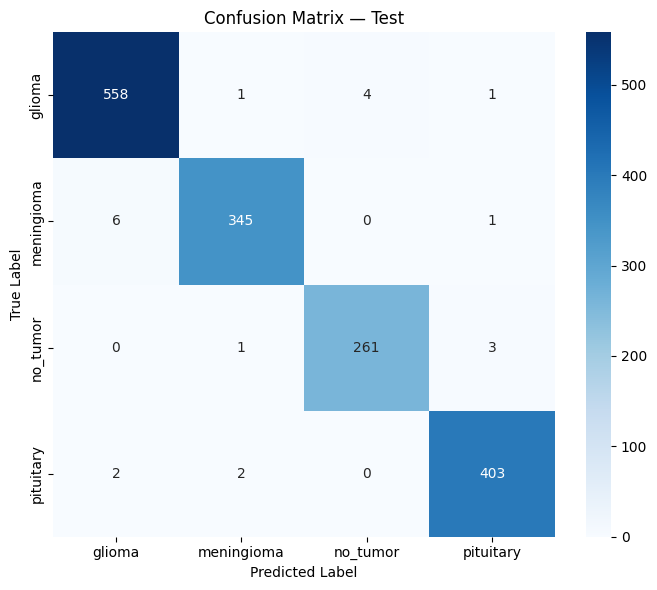

  ✅ Saved → /content/drive/MyDrive/model_artifacts/cm_test.png


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ── Config ─────────────────────────────────────────────────────────
VAL_DIR     = "/content/drive/MyDrive/MRI_Imagess_split/val"
TEST_DIR    = "/content/drive/MyDrive/MRI_Imagess_split/test"
MODEL_PATH  = "/content/drive/MyDrive/model_artifacts/vgg16_final.keras"
CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
IMAGE_SIZE  = 224
BATCH_SIZE  = 32
OUT_DIR     = "/content/drive/MyDrive/model_artifacts"

# ── Load model ─────────────────────────────────────────────────────
print("Loading model...")
model = load_model(MODEL_PATH)
print("✅ Model loaded.")

# ── Rebuild paths ──────────────────────────────────────────────────
def gather_paths_labels(root_dir, class_names):
    paths, labels = [], []
    for cls in class_names:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.png','.jpg','.jpeg')):
                paths.append(os.path.join(cls_dir, fname))
                labels.append(cls)
    return paths, labels

val_paths,  val_labels  = gather_paths_labels(VAL_DIR,  CLASS_NAMES)
test_paths, test_labels = gather_paths_labels(TEST_DIR, CLASS_NAMES)
print(f"Val: {len(val_paths)} | Test: {len(test_paths)}")

# ── Evaluate ───────────────────────────────────────────────────────
def evaluate(split_name, paths, labels):
    print(f"\n{'='*50}")
    print(f"  EVALUATION — {split_name}")
    print(f"{'='*50}")

    all_preds, all_trues = [], []

    for i in range(0, len(paths), BATCH_SIZE):
        batch_paths  = paths[i:i+BATCH_SIZE]
        batch_labels = labels[i:i+BATCH_SIZE]
        imgs = []
        for p in batch_paths:
            try:
                img = load_img(p, target_size=(IMAGE_SIZE, IMAGE_SIZE))
                arr = preprocess_input(
                    img_to_array(img).astype(np.float32))
                imgs.append(arr)
            except:
                continue
        if not imgs:
            continue
        X     = np.stack(imgs)
        preds = model.predict(X, verbose=0)
        all_preds.extend(np.argmax(preds, axis=1).tolist())
        all_trues.extend([CLASS_NAMES.index(l) for l in batch_labels])

    all_preds = np.array(all_preds)
    all_trues = np.array(all_trues)
    acc       = accuracy_score(all_trues, all_preds)

    print(f"\n  Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(classification_report(all_trues, all_preds,
                                target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(all_trues, all_preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix — {split_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    save_path = os.path.join(OUT_DIR, f"cm_{split_name.lower()}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"  ✅ Saved → {save_path}")

evaluate("Validation", val_paths, val_labels)
evaluate("Test",       test_paths, test_labels)

In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive/mri_brain_prototype.pkl"))

False


In [30]:
import os, cv2, pickle
import numpy as np
from google.colab import drive
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

drive.mount('/content/drive')

# ── Config ─────────────────────────────────────────────────────────
MODEL_PATH  = "/content/drive/MyDrive/model_artifacts/vgg16_final.keras"
CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
IMAGE_SIZE  = 224
CONF_THRESHOLD = 0.55

# ── Load model ─────────────────────────────────────────────────────
print("Loading model...")
model = load_model(MODEL_PATH)
print("✅ Ready.\n")

# ── Rejection filter ───────────────────────────────────────────────
def _pixel_check(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return False, "Cannot read image"
    img      = cv2.resize(img_bgr, (IMAGE_SIZE, IMAGE_SIZE))
    gray     = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv      = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mean_sat = float(hsv[:,:,1].mean())

    # reject clearly colorful/natural images
    if mean_sat > 180:
        return False, f"Natural photo (sat={mean_sat:.1f})"

    failures     = []
    dark_ratio   = float(np.sum(gray < 30) / gray.size)
    bright_ratio = float(np.sum(gray > 80) / gray.size)

    if dark_ratio   < 0.05: failures.append(f"no dark bg ({dark_ratio:.3f})")
    if mean_sat     > 160:  failures.append(f"high sat ({mean_sat:.1f})")
    if bright_ratio > 0.85: failures.append(f"too bright/X-ray ({bright_ratio:.2f})")

    edges = cv2.Canny(gray, 50, 150)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180,
                threshold=80, minLineLength=60, maxLineGap=10)
    n_lines      = len(lines) if lines is not None else 0
    edge_density = float(edges.sum() / (gray.size * 255))
    if edge_density > 0.10 and n_lines > 30:
        failures.append("X-ray pattern")

    if len(failures) >= 2:
        return False, " + ".join(failures)
    return True, "ok"

# ── Predict ────────────────────────────────────────────────────────
def predict(image_path):
    print(f"🔍 {os.path.basename(image_path)}")

    # Step 1: rule-based rejection
    ok, reason = _pixel_check(image_path)
    if not ok:
        print(f"🚫 REJECTED — {reason}")
        print("   ⛔ Please upload a valid Brain MRI input\n")
        return

    # Step 2: preprocess
    img = load_img(image_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    arr = preprocess_input(img_to_array(img).astype(np.float32))
    inp = np.expand_dims(arr, axis=0)

    # Step 3: predict
    preds = model.predict(inp, verbose=0)[0]
    top_i = int(np.argmax(preds))
    conf  = float(preds[top_i])

    # Step 4: confidence check
    if conf < CONF_THRESHOLD:
        print(f"🚫 REJECTED — Low confidence ({conf*100:.1f}%)")
        print("   ⛔ Please upload a valid Brain MRI input\n")
        return

    print(f"✅ ACCEPTED")
    print(f"   Class      : {CLASS_NAMES[top_i].upper()}")
    print(f"   Confidence : {conf*100:.1f}%")
    for i, cls in enumerate(CLASS_NAMES):
        bar = "█" * int(preds[i] * 30)
        print(f"   {cls:<14} {bar:<30} {preds[i]*100:.1f}%")
    print()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading model...
✅ Ready.



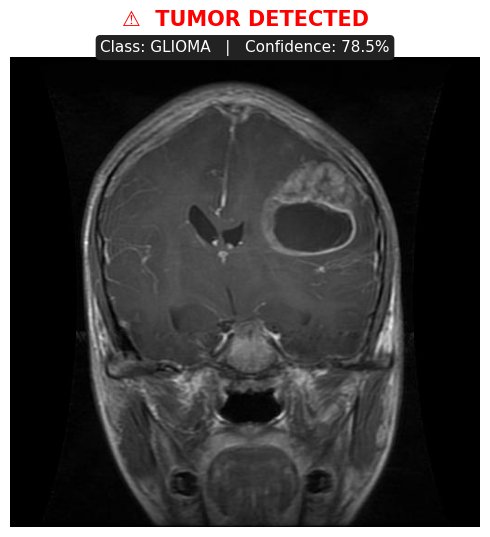

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

IMAGE_SIZE     = 224
CONF_THRESHOLD = 0.55

def _pixel_check(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return False, "Cannot read image"
    img      = cv2.resize(img_bgr, (IMAGE_SIZE, IMAGE_SIZE))
    gray     = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv      = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mean_sat = float(hsv[:,:,1].mean())

    if mean_sat > 180:
        return False, f"Natural photo (sat={mean_sat:.1f})"

    failures     = []
    dark_ratio   = float(np.sum(gray < 30) / gray.size)
    bright_ratio = float(np.sum(gray > 80) / gray.size)

    if dark_ratio   < 0.05: failures.append(f"no dark bg ({dark_ratio:.3f})")
    if mean_sat     > 160:  failures.append(f"high sat ({mean_sat:.1f})")
    if bright_ratio > 0.85: failures.append(f"too bright ({bright_ratio:.2f})")

    edges = cv2.Canny(gray, 50, 150)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180,
                threshold=80, minLineLength=60, maxLineGap=10)
    n_lines      = len(lines) if lines is not None else 0
    edge_density = float(edges.sum() / (gray.size * 255))
    if edge_density > 0.10 and n_lines > 30:
        failures.append("X-ray pattern")

    if len(failures) >= 2:
        return False, " + ".join(failures)
    return True, "ok"


def show_prediction(image_path, model, class_names):

    # Step 1: rejection check
    ok, reason = _pixel_check(image_path)
    if not ok:
        fig, ax = plt.subplots(figsize=(5, 4))
        ax.set_facecolor('black')
        fig.patch.set_facecolor('black')
        ax.text(0.5, 0.6, "⛔ INVALID INPUT",
                transform=ax.transAxes,
                fontsize=16, fontweight='bold',
                color='red', ha='center', va='center')
        ax.text(0.5, 0.4,
                "Please upload a valid\nBrain MRI image",
                transform=ax.transAxes,
                fontsize=12, color='white',
                ha='center', va='center')
        ax.axis('off')
        plt.tight_layout()
        plt.show()
        return

    # Step 2: preprocess + predict
    img   = load_img(image_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    arr   = preprocess_input(img_to_array(img).astype(np.float32))
    preds = model.predict(np.expand_dims(arr, axis=0), verbose=0)[0]
    top_i = int(np.argmax(preds))
    conf  = float(preds[top_i]) * 100
    cls   = class_names[top_i]

    # Step 3: confidence check
    if conf < CONF_THRESHOLD * 100:
        fig, ax = plt.subplots(figsize=(5, 4))
        ax.set_facecolor('black')
        fig.patch.set_facecolor('black')
        ax.text(0.5, 0.6, "⛔ INVALID INPUT",
                transform=ax.transAxes,
                fontsize=16, fontweight='bold',
                color='red', ha='center', va='center')
        ax.text(0.5, 0.4,
                "Please upload a valid\nBrain MRI image",
                transform=ax.transAxes,
                fontsize=12, color='white',
                ha='center', va='center')
        ax.axis('off')
        plt.tight_layout()
        plt.show()
        return

    # Step 4: show result
    has_tumor = cls != 'no_tumor'
    status    = "⚠  TUMOR DETECTED" if has_tumor else "✓  NO TUMOR DETECTED"
    color     = "red" if has_tumor else "green"

    fig, ax = plt.subplots(figsize=(5, 6))
    ax.imshow(load_img(image_path))
    ax.axis('off')
    ax.text(0.5, 1.08, status,
            transform=ax.transAxes,
            fontsize=15, fontweight='bold',
            color=color, ha='center', va='center')
    ax.text(0.5, 1.02,
            f"Class: {cls.upper()}   |   Confidence: {conf:.1f}%",
            transform=ax.transAxes,
            fontsize=11, color='white', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#222222', edgecolor='none'))
    plt.tight_layout()
    plt.show()


# ← replace with your path
show_prediction(
    "/content/drive/MyDrive/MRI_Imagess_split/test/glioma/glioma1835.jpg",
    model,
    CLASS_NAMES
)

Saving P_418.jpg to P_418.jpg


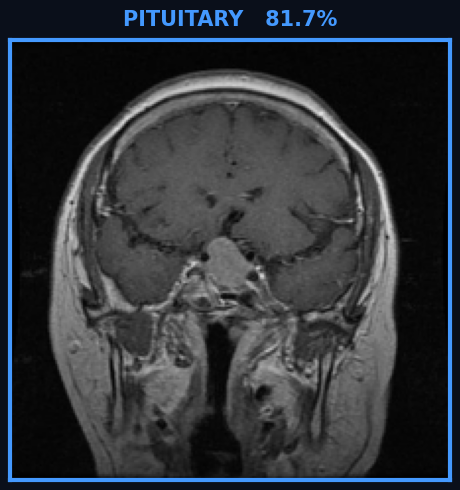

In [59]:
from google.colab import files
import numpy as np, cv2, matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
from PIL import Image

# OOD thresholds (copied from preprocessing.py, cell sI7sL7RpACwh)
OOD_CONFIG = {
    "mahalanobis_threshold" : 12.0,
    "confidence_threshold"  : 0.55,
    "entropy_threshold"     : 0.90,
    "min_dark_pixel_ratio"  : 0.05,
    "max_saturation"        : 160,
    "min_parallel_lines"    : 30,
    "max_edge_density"      : 0.10,
}

# Redefine _pixel_check to correctly accept an image array (img_bgr)
# This overrides the problematic global _pixel_check defined in f6v73oI0A2G2
def _pixel_check(img_bgr):
    failures = []
    gray     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hsv      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    mean_sat = float(hsv[:, :, 1].mean())
    if mean_sat > 180:
        return False, f"Clearly a natural photo (sat={mean_sat:.1f})"

    dark_ratio = float(np.sum(gray < 30) / gray.size)
    if dark_ratio < OOD_CONFIG["min_dark_pixel_ratio"]:
        failures.append(f"no dark bg ({dark_ratio:.3f})")

    if mean_sat > OOD_CONFIG["max_saturation"]:
        failures.append(f"high saturation ({mean_sat:.1f})")

    edges          = cv2.Canny(gray, 50, 150)
    lines          = cv2.HoughLinesP(edges, 1, np.pi/180,
                        threshold=80, minLineLength=60, maxLineGap=10)
    parallel_lines = len(lines) if lines is not None else 0
    edge_density   = float(edges.sum() / (gray.size * 255))

    if (edge_density   > OOD_CONFIG["max_edge_density"] and
        parallel_lines > OOD_CONFIG["min_parallel_lines"]):
        failures.append(f"X-ray pattern ({parallel_lines} lines)")

    if len(failures) >= 2:
        return False, " + ".join(failures)

    return True, "passed"

uploaded  = files.upload()
fname     = list(uploaded.keys())[0]

# ── Decode ────────────────────────────────────────────────────────
nparr     = np.frombuffer(uploaded[fname], np.uint8)
img_bgr   = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
img_rgb   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_show  = cv2.resize(img_rgb, (IMAGE_SIZE, IMAGE_SIZE))

# ── Validate ──────────────────────────────────────────────────────
ok, reason = _pixel_check(img_bgr)

# ── Preprocess + predict ──────────────────────────────────────────
arr   = preprocess_input(img_to_array(Image.fromarray(img_show)).astype('float32'))
preds = model.predict(np.expand_dims(arr, 0), verbose=0)[0]
top   = int(np.argmax(preds))
conf  = float(preds[top])
cls   = CLASS_NAMES[top]

rejected = not ok or conf < CONF_THRESHOLD

# ── Show result ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor('#0a0f1a')

if rejected:
    ax.set_facecolor('#080c10')
    ax.text(0.5, 0.55, '⛔ REJECTED',  transform=ax.transAxes,
            fontsize=18, fontweight='bold', color='red', ha='center')
    ax.text(0.5, 0.40, 'Please upload a valid Brain MRI',
            transform=ax.transAxes, fontsize=10, color='#aaaaaa', ha='center')
    ax.text(0.5, 0.28, reason if not ok else f"Low confidence ({conf*100:.1f}%)",
            transform=ax.transAxes, fontsize=8, color='#ff6666',
            ha='center', style='italic')
else:
    COLOR = {'glioma':'#ff4444','meningioma':'#ffaa00',
             'no_tumor':'#00dd77','pituitary':'#4499ff'}.get(cls, '#ffffff')
    ax.imshow(img_show)
    ax.set_title(f'{cls.upper()}   {conf*100:.1f}%',
                 fontsize=15, fontweight='bold', color=COLOR, pad=10)
    for sp in ax.spines.values():
        sp.set_edgecolor(COLOR); sp.set_linewidth(3)

ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

In [7]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    path = f"/content/{filename}"
    predict(path)

Saving glioma3635.jpg to glioma3635.jpg
🔍 glioma3635.jpg
✅ ACCEPTED
   Class      : GLIOMA
   Confidence : 81.9%
   glioma         ████████████████████████       81.9%
   meningioma     █                              6.0%
   no_tumor       █                              5.2%
   pituitary      ██                             6.9%



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading model...
✅ Ready.



/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Saving glioma2779.jpg to glioma2779.jpg
🔍 glioma2779.jpg


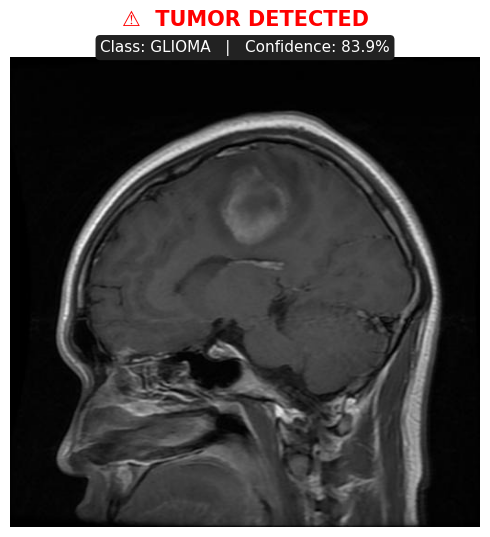

✅ GLIOMA — 83.9%



In [5]:
import os, cv2, numpy as np, matplotlib.pyplot as plt
from google.colab import drive
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

drive.mount('/content/drive')

# ── Config ─────────────────────────────────────────────────────────
MODEL_PATH     = "/content/drive/MyDrive/model_artifacts/vgg16_final.keras"
CLASS_NAMES    = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
IMAGE_SIZE     = 224
CONF_THRESHOLD = 0.55

# ── Load model ─────────────────────────────────────────────────────
print("Loading model...")
model = load_model(MODEL_PATH)
print("✅ Ready.\n")

# ── Rejection filter ───────────────────────────────────────────────
def is_valid_mri(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return False, "Cannot read image"
    img      = cv2.resize(img_bgr, (IMAGE_SIZE, IMAGE_SIZE))
    gray     = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv      = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mean_sat = float(hsv[:,:,1].mean())
    if mean_sat > 180:
        return False, "Natural photo"
    failures     = []
    dark_ratio   = float(np.sum(gray < 30)  / gray.size)
    bright_ratio = float(np.sum(gray > 80)  / gray.size)
    if dark_ratio   < 0.05: failures.append("no dark background")
    if mean_sat     > 160:  failures.append("colorful image")
    if bright_ratio > 0.85: failures.append("too bright / X-ray")
    edges        = cv2.Canny(gray, 50, 150)
    lines        = cv2.HoughLinesP(edges, 1, np.pi/180,
                       threshold=80, minLineLength=60, maxLineGap=10)
    n_lines      = len(lines) if lines is not None else 0
    edge_density = float(edges.sum() / (gray.size * 255))
    if edge_density > 0.10 and n_lines > 30:
        failures.append("X-ray pattern")
    if len(failures) >= 2:
        return False, " + ".join(failures)
    return True, "ok"

# ── Rejected display ───────────────────────────────────────────────
def show_rejected():
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.set_facecolor('black')
    fig.patch.set_facecolor('black')
    ax.text(0.5, 0.58, "⛔  INVALID INPUT",
            transform=ax.transAxes,
            fontsize=17, fontweight='bold',
            color='red', ha='center', va='center')
    ax.text(0.5, 0.42,
            "Please upload a valid Brain MRI image",
            transform=ax.transAxes,
            fontsize=11, color='white',
            ha='center', va='center')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# ── Main predict ───────────────────────────────────────────────────
def predict(image_path):
    print(f"🔍 {os.path.basename(image_path)}")
    ok, reason = is_valid_mri(image_path)
    if not ok:
        print(f"🚫 Rejected — {reason}\n")
        show_rejected()
        return
    img   = load_img(image_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    arr   = preprocess_input(img_to_array(img).astype(np.float32))
    preds = model.predict(np.expand_dims(arr, axis=0), verbose=0)[0]
    top_i = int(np.argmax(preds))
    conf  = float(preds[top_i])
    cls   = CLASS_NAMES[top_i]
    if conf < CONF_THRESHOLD:
        print(f"🚫 Rejected — low confidence ({conf*100:.1f}%)\n")
        show_rejected()
        return
    has_tumor = cls != 'no_tumor'
    status    = "⚠  TUMOR DETECTED"  if has_tumor else "✓  NO TUMOR DETECTED"
    color     = "red"                 if has_tumor else "green"
    fig, ax = plt.subplots(figsize=(5, 6))
    ax.imshow(load_img(image_path))
    ax.axis('off')
    ax.text(0.5, 1.08, status,
            transform=ax.transAxes,
            fontsize=15, fontweight='bold',
            color=color, ha='center', va='center')
    ax.text(0.5, 1.02,
            f"Class: {cls.upper()}   |   Confidence: {conf*100:.1f}%",
            transform=ax.transAxes,
            fontsize=11, color='white',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#222222', edgecolor='none'))
    plt.tight_layout()
    plt.show()
    print(f"✅ {cls.upper()} — {conf*100:.1f}%\n")

# ── Test via browse ────────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()
for filename in uploaded.keys():
    predict(f"/content/{filename}")

In [29]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    path = f"/content/{filename}"
    predict(path)

Saving Te-no_0254.jpg to Te-no_0254.jpg
🔍 Te-no_0254.jpg
✅ ACCEPTED
   Class      : NO_TUMOR
   Confidence : 82.4%
   glioma         █                              5.6%
   meningioma     █                              6.1%
   no_tumor       ████████████████████████       82.4%
   pituitary      █                              5.9%



In [4]:
from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/model_artifacts/vgg16_final.h5")
model.save("/content/drive/MyDrive/model_artifacts/vgg16_final.keras")
print("✅ Resaved as .keras")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ Resaved as .keras
